# Truss analysis -- statics + linear algebra for civil engineering
### the method of joints is one matrix equation A f = -load

A truss carries load as pure tension/compression in its straight members. Write static
equilibrium at each joint -- $\sum F_x=0$, $\sum F_y=0$ -- and you get **two linear
equations per node**. Stack them: a single linear system
$$A\,\mathbf f = -\mathbf{load},$$
whose unknowns are the member forces and support reactions, solved with
`np.linalg.solve`. Tension is positive, compression negative. This is how every roof,
bridge, and crane truss is sized -- the statics of `dgs.statics` turned into linear
algebra (the same $A\mathbf x=\mathbf b$ as the SPICE nodal analysis). Uses
`dgs/truss.py`. Civilian education / civil engineering.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import truss as tr

def plot_truss(nodes, members, mf, loads, title):
    fmax = max(abs(f) for f in mf.values()) or 1.0
    plt.figure(figsize=(7.5, 4))
    for (a, c), f in mf.items():
        xs = [nodes[a][0], nodes[c][0]]; ys = [nodes[a][1], nodes[c][1]]
        col = "C0" if f > 0 else "C3"                       # tension blue, compression red
        plt.plot(xs, ys, color=col, lw=1 + 5*abs(f)/fmax, solid_capstyle="round", zorder=1)
        plt.text(np.mean(xs), np.mean(ys), f"{f:+.1f}", fontsize=8, ha="center",
                 bbox=dict(fc="white", ec="none", alpha=0.7))
    for n, (x, y) in nodes.items():
        plt.scatter([x], [y], s=60, color="k", zorder=3); plt.text(x, y+0.12, n, fontsize=9)
    for n, (fx, fy) in loads.items():
        plt.annotate("", xy=(nodes[n][0]+fx*0.05, nodes[n][1]+fy*0.05), xytext=nodes[n],
                     arrowprops=dict(arrowstyle="-|>", color="green", lw=2))
    plt.plot([], [], "C0", label="tension"); plt.plot([], [], "C3", label="compression")
    plt.legend(loc="upper right"); plt.axis("equal"); plt.title(title); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
print("ready")

ready


## 1. A triangular truss -- solved as linear algebra

Pin at A, roller at B, a 10 kN load hung at the apex C. The method of joints builds
the matrix; solving it gives the member forces. The two sloping members push back
(compression), the bottom tie pulls (tension).

  ('A', 'C'): -7.071 kN  (compression)
  ('B', 'C'): -7.071 kN  (compression)
  ('A', 'B'): +5.000 kN  (tension)
  reactions: {'A': (0.0, 5.0), 'B': (0.0, 5.0)}


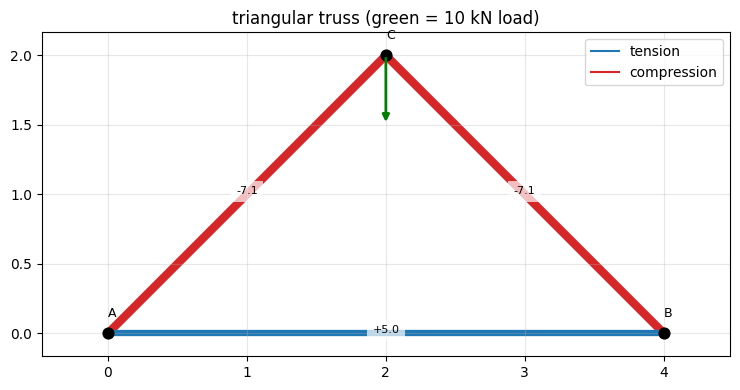

In [2]:
nodes = {"A": (0,0), "B": (4,0), "C": (2,2)}
members = [("A","C"), ("B","C"), ("A","B")]
supports = {"A": (True,True), "B": (False,True)}
loads = {"C": (0.0, -10.0)}
mf, rx = tr.solve_truss(nodes, members, supports, loads)
for m, f in mf.items():
    print(f"  {m}: {f:+.3f} kN  ({'tension' if f>0 else 'compression'})")
print("  reactions:", {n: tuple(round(c,2) for c in v) for n,v in rx.items()})
plot_truss(nodes, members, mf, loads, "triangular truss (green = 10 kN load)")

## 2. A two-panel Warren truss (a little bridge)

Add panels and you get a bridge span. Under a central load the **top chord goes into
compression** and the **bottom chord into tension** -- the universal signature of a
simply-supported span, and exactly why you put a strong material on top and a stiff
tie on the bottom. The diagonals shuttle the shear to the supports.

determinate (m+r = 2n): True


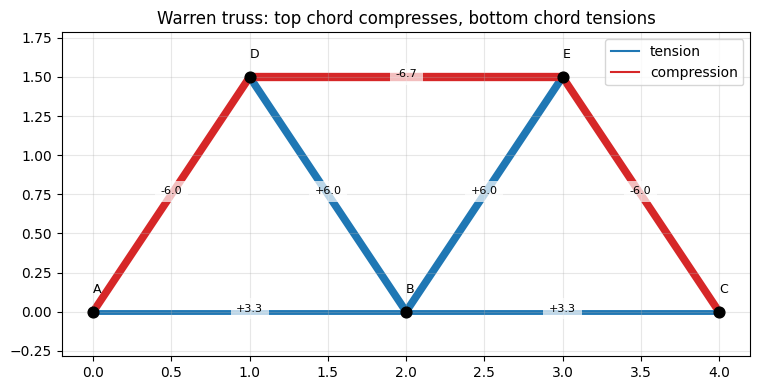

top chord D-E = -6.67 kN (compression); bottom A-B = 3.33 kN (tension)


In [3]:
nodes = {"A":(0,0), "B":(2,0), "C":(4,0), "D":(1,1.5), "E":(3,1.5)}
members = [("A","D"),("D","B"),("B","E"),("E","C"),("D","E"),("A","B"),("B","C")]
supports = {"A": (True,True), "C": (False,True)}
loads = {"B": (0.0, -10.0)}
print("determinate (m+r = 2n):", tr.is_determinate(5, 7, 3))
mf, rx = tr.solve_truss(nodes, members, supports, loads)
plot_truss(nodes, members, mf, loads, "Warren truss: top chord compresses, bottom chord tensions")
print("top chord D-E =", round(mf[('D','E')],2), "kN (compression);",
      "bottom A-B =", round(mf[('A','B')],2), "kN (tension)")

## 3. Determinacy -- can the truss even stand?

A 2-D truss is **statically determinate** (solvable by statics alone) when
$$\text{members} + \text{reactions} = 2\times\text{nodes}.$$
Too few members and it is a **mechanism** -- it folds up (the matrix is singular). Too
many and it is statically indeterminate (you need the members' stiffness). Counting is
the first thing a structural engineer checks.

In [4]:
for (n, m, r, name) in [(3,3,3,"triangle"), (5,7,3,"2-panel Warren"),
                        (3,2,3,"triangle missing a tie")]:
    print(f"  {name:24s}: m+r={m+r}, 2n={2*n} -> "
          f"{'determinate (stable)' if tr.is_determinate(n,m,r) else 'MECHANISM / unstable'}")

  triangle                : m+r=6, 2n=6 -> determinate (stable)
  2-panel Warren          : m+r=10, 2n=10 -> determinate (stable)
  triangle missing a tie  : m+r=5, 2n=6 -> MECHANISM / unstable


## What ties together

1. **Method of joints = linear algebra:** equilibrium at every joint ($\sum F=0$)
   stacks into $A\mathbf f=-\mathbf{load}$, solved with one matrix inverse.
2. **The force pattern is structural intuition:** simply-supported spans put the top
   chord in compression and the bottom in tension.
3. **Determinacy** ($m+r=2n$) tells you up front whether statics alone can solve it --
   or whether it folds.

It is the same $A\mathbf x=\mathbf b$ as the SPICE nodal analysis (`dgs.spice`) and the
same statics as `dgs.statics`: physics becomes a matrix, and linear algebra sizes the
structure. Civilian education / civil engineering.